In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing

In [ ]:
df=pd.read_excel("Online Retail.xlsx")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
df["Date"]=pd.to_datetime(df["InvoiceDate"], format = '%Y-%m-%d %H:%M:%S')

def unique_counts(df):
  for i in df.columns:
    count = df[i].nunique()
    print(i, ": ", count)
unique_counts(df)

InvoiceNo :  25900
StockCode :  4070
Description :  4223
Quantity :  722
InvoiceDate :  23260
UnitPrice :  1630
CustomerID :  4372
Country :  38
Date :  23260


In [ ]:
df['Total_Price']=df['Quantity']*df['UnitPrice']
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Date,Total_Price
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2010-12-01 08:26:00,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12-01 08:26:00,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,2010-12-01 08:26:00,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12-01 08:26:00,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12-01 08:26:00,20.34
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom,2010-12-01 08:26:00,15.30
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom,2010-12-01 08:26:00,25.50
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom,2010-12-01 08:28:00,11.10
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom,2010-12-01 08:28:00,11.10
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom,2010-12-01 08:34:00,54.08


In [ ]:
Online_retail_df = df[np.isfinite(df['CustomerID'])]


In [ ]:
unique_counts(Online_retail_df)

InvoiceNo :  22190
StockCode :  3684
Description :  3896
Quantity :  436
InvoiceDate :  20460
UnitPrice :  620
CustomerID :  4372
Country :  37
Date :  20460
Total_Price :  4041


In [ ]:
final_retail = Online_retail_df[Online_retail_df['Quantity']>0]

In [ ]:
final_retail.shape

(397924, 10)

In [ ]:
unique_counts(final_retail)

InvoiceNo :  18536
StockCode :  3665
Description :  3877
Quantity :  302
InvoiceDate :  17286
UnitPrice :  441
CustomerID :  4339
Country :  37
Date :  17286
Total_Price :  2940


In [ ]:
type(final_retail["Date"].max())

pandas._libs.tslibs.timestamps.Timestamp

In [ ]:
final_retail['Date'].min()

Timestamp('2010-12-01 08:26:00')

##Calculate RFM value for each customer

In [ ]:
import datetime as dt
NOW = dt.datetime(2011,12,10)

In [ ]:
rfmTable = final_retail.groupby('CustomerID').agg({'Date': lambda x: (NOW - x.max()).days,
                                                   'InvoiceNo': lambda x: len(x),
                                                   'Total_Price': lambda x: x.sum()})

rfmTable['Date'] = rfmTable['Date'].astype(int)
rfmTable.rename(columns={'Date': 'recency',
                         'InvoiceNo': 'frequency',
                         'Total_Price': 'monetary_value'},inplace=True)

In [ ]:
rfmTable.shape

(4339, 3)

In [ ]:
rfmTable.head()

,recency,frequency,monetary_value
CustomerID,,,
12346.0,325,1,77183.60
12347.0,2,182,4310.00
12348.0,75,31,1797.24
12349.0,18,73,1757.55
12350.0,310,17,334.40


##Recency(R): Time sinc last purchase
##Frequency(F): Total number of purchase
##Monetary Value(M):Total monetary value

In [ ]:
rfmTable.sort_values(['frequency', 'monetary_value'], ascending=[False, False], inplace=True)

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform( rfmTable)

In [ ]:
clusters = KMeans(3)
clusters.fit(X_scaled)

KMeans(n_clusters=3)

In [ ]:
rfmTable["cluster_new"]=clusters.labels_

In [ ]:
rfmTable.groupby('cluster_new').mean()

,recency,frequency,monetary_value
cluster_new,,,
0,40.929473,103.056360,2028.041251
1,246.911956,27.749768,636.533764
2,4.000000,2566.000000,126118.310000


In [ ]:
#High recency and low frequency and low monetary value
rfmTable_0 = rfmTable[rfmTable.cluster_new==0]

In [ ]:
rfmTable_0.head(10)

,recency,frequency,monetary_value,cluster_new
CustomerID,,,,
14606.0,1,2700,12156.65,0
13263.0,1,1677,7454.07,0
14298.0,8,1637,51527.30,0
15039.0,9,1502,19914.44,0
18118.0,10,1279,5653.82,0
14159.0,19,1204,4693.01,0
14796.0,1,1141,8022.49,0
16033.0,5,1137,8816.40,0
15005.0,15,1119,6316.57,0


In [ ]:
#Decent frequency and monetary value
rfmTable_1 = rfmTable[rfmTable.cluster_new==1]
rfmTable_1.head(10)

,recency,frequency,monetary_value,cluster_new
CustomerID,,,,
17850.0,372,297,5391.21,1
15644.0,166,238,813.00,1
14573.0,179,235,1653.42,1
15808.0,306,208,3734.97,1
15379.0,169,194,3703.29,1
17341.0,156,183,781.36,1
17472.0,191,181,710.29,1
14669.0,241,170,1269.99,1
15574.0,177,168,702.25,1


In [ ]:
#low recency and high frequency and monetary value
rfmTable_2 = rfmTable[rfmTable.cluster_new==2]
rfmTable_2.head(10)

,recency,frequency,monetary_value,cluster_new
CustomerID,,,,
17841.0,1,7847,40991.57,2
14911.0,1,5677,143825.06,2
14096.0,4,5111,65164.79,2
12748.0,0,4596,33719.73,2
15311.0,0,2379,60767.90,2
14646.0,1,2080,280206.02,2
13089.0,2,1818,58825.83,2
14156.0,9,1400,117379.63,2
17511.0,2,963,91062.38,2


In [ ]:
rfmTable_0.mean()

,0
recency,40.929473
frequency,103.056360
monetary_value,2028.041251
cluster_new,0.000000


In [ ]:
rfmTable_1.mean()

,0
recency,246.911956
frequency,27.749768
monetary_value,636.533764
cluster_new,1.000000


In [ ]:
rfmTable_2.mean()

,0
recency,4.00
frequency,2566.00
monetary_value,126118.31
cluster_new,2.00


##Dendogram built with random samples from X_scaled

In [ ]:
import random
random.seed(9008)
X_sample = np.array(random.sample(X_scaled.tolist(),20))
#type(X_scaled)

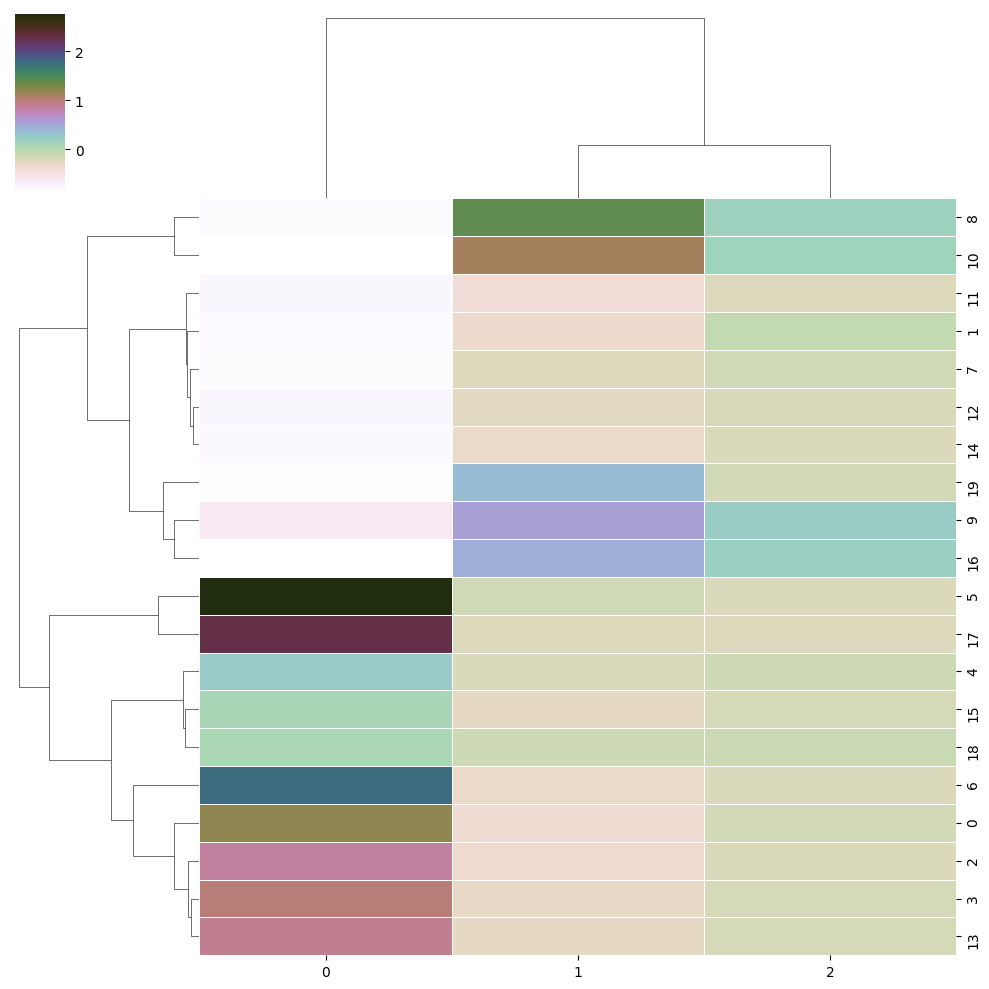

In [ ]:
cmap = sns.cubehelix_palette(as_cmap=True, rot=-3, light=1)
g = sns.clustermap(X_sample, cmap=cmap, linewidths = .5)